# Family B — strategy showcase: the FLY25 carry short and the STRG75 richness fade

The two surviving structures from the dispersion program
(`2026-08-04-family-b-dispersion-findings.md`), presented as full research
backtests in the house layout:

1. **Short FLY25 Q1** — the defined-risk dispersion short: sell the modal
   25bp butterfly on the front quarterly, rolled at expiry−3d. The wings
   cap event risk (worst day −4.2bp through SVB), unlike the strangle
   shorts this book replaced (worst days −55/−92bp).
2. **STRG75 Q1 intra-quarter richness fade** — sell the ±75bp strangle
   only when its listed premium is ≥ thr over the ZQ-tree fair value,
   exit at 25% of entry richness or 15 sessions; never held to expiry.

Provenance and honesty (from the findings doc, restated up front): the
carry short's NW t is 1.51 — real-looking but NOT significant; the fade
winner came out of a 720-config search — **DSR 0.000, house verdict
SELECTION-ARTIFACT** — mechanism-supported (7–18 session half-lives,
frontier-consistent richness levels) but search-uncertified. This
notebook is the pre-registration instrument, not a certification.

Everything below recomputes from listed premiums (parity-completed
surface), serff settles, and the ZQ lattice — change `CONFIG` and re-run.

In [1]:
CONFIG = dict(
    # -- strategy 1: the carry book ------------------------------------
    carry_book="FLY25",          # FLY25 | FLY50 | DFLY | STRG50 | STRG75
    carry_rank=1,                # 1 = front quarterly
    carry_side="short",          # long | short
    # -- strategy 2: the intra-quarter richness fade -------------------
    fade_book="STRG75",
    fade_rank=1,
    fade_thr_bp=4.0,             # entry when |rich| >= thr
    fade_exit_frac=0.25,         # exit when |rich| <= frac * entry
    fade_max_hold=15,            # sessions
    fade_direction="fade",       # fade | momentum
    # -- shared ---------------------------------------------------------
    cost_mult=1.0,               # headline cost multiplier (half-ticks)
    cost_scenarios=(0.0, 1.0, 2.0),
    n_packages=100,              # position size for $ figures
    dollars_per_bp=25.0,         # SR3 option DV01 per contract-lot
    start=None,                  # e.g. "2022-01-01" to clip the sample
    end=None,
    rolling_window=63,           # sessions, for rolling Sharpe/vol panels
)
CONFIG

{'carry_book': 'FLY25',
 'carry_rank': 1,
 'carry_side': 'short',
 'fade_book': 'STRG75',
 'fade_rank': 1,
 'fade_thr_bp': 4.0,
 'fade_exit_frac': 0.25,
 'fade_max_hold': 15,
 'fade_direction': 'fade',
 'cost_mult': 1.0,
 'cost_scenarios': (0.0, 1.0, 2.0),
 'n_packages': 100,
 'dollars_per_bp': 25.0,
 'start': None,
 'end': None,
 'rolling_window': 63}

In [2]:
import sys

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(".")
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from famb_common import (
    TreeCtx, attribution, book_daily_pnl, build_book, intra_quarter_backtest,
    load_quotes, n_contracts, premium_surface, richness_frame, sr3_forwards,
    trades_daily_pnl,
)
from RVUtils.SFRRVLab.stats import nw_tstat
from SDRUtils.analytics.fomc import load_fomc_schedule

DPB = CONFIG["dollars_per_bp"] * CONFIG["n_packages"]

quotes = load_quotes()
if CONFIG["start"]:
    quotes = quotes[quotes["as_of"] >= CONFIG["start"]]
if CONFIG["end"]:
    quotes = quotes[quotes["as_of"] <= CONFIG["end"]]
symbols = sorted(quotes["symbol"].unique())
fwd = sr3_forwards(symbols)
fwd["as_of"] = pd.to_datetime(fwd["as_of"])
surface = premium_surface(quotes, fwd)
fwd_idx = fwd.set_index(["as_of", "symbol"])["fwd_rate"].sort_index()
dates = pd.DatetimeIndex(sorted(quotes["as_of"].unique()))
tree = TreeCtx([d.date() for d in dates])
fomc = load_fomc_schedule("USD-SOFR-1D")
decisions = [pd.Timestamp(d).date() for d in fomc["effective_date"]
             if dates[0] <= pd.Timestamp(d) <= dates[-1]]
print(f"sample {dates[0].date()} -> {dates[-1].date()}  |  "
      f"{len(quotes):,} quotes, {len(symbols)} symbols, "
      f"{len(decisions)} FOMC decisions")

sample 2021-02-04 -> 2026-07-28  |  376,503 quotes, 26 symbols, 43 FOMC decisions


## Reporting blocks (house layout)

In [3]:
def perf_stats(daily: pd.Series, trades_n=None, hit=None) -> dict:
    d = daily.dropna()
    if len(d) < 5:
        return {"days": len(d)}
    sd = d.std(ddof=1)
    downside = d[d < 0].std(ddof=1)
    eq = d.cumsum()
    dd = eq - eq.cummax()
    in_dd = dd < 0
    runs = (in_dd != in_dd.shift()).cumsum()[in_dd]
    dd_len = int(runs.value_counts().max()) if len(runs) else 0
    gains, losses = d[d > 0].sum(), -d[d < 0].sum()
    yrs = (d.index[-1] - d.index[0]).days / 365.25
    return {
        "days": int(len(d)), "years": round(yrs, 2),
        "total_bp": round(float(d.sum()), 1),
        "bp_per_year": round(float(d.sum() / yrs), 1) if yrs > 0 else np.nan,
        "total_usd": round(float(d.sum() * DPB), 0),
        "sharpe_ann": round(float(d.mean() / sd * np.sqrt(252)), 2)
        if sd > 0 else np.nan,
        "sortino_ann": round(float(d.mean() / downside * np.sqrt(252)), 2)
        if downside and downside > 0 else np.nan,
        "nw_t": round(float(nw_tstat(d.to_numpy())), 2),
        "hit_days": round(float((d > 0).mean()), 2),
        "max_dd_bp": round(float(dd.min()), 1),
        "max_dd_usd": round(float(dd.min() * DPB), 0),
        "dd_len_max_days": dd_len,
        "worst_day_bp": round(float(d.min()), 2),
        "best_day_bp": round(float(d.max()), 2),
        "skew": round(float(d.skew()), 2),
        "kurtosis": round(float(d.kurtosis()), 2),
        "profit_factor": round(float(gains / losses), 2)
        if losses > 0 else np.inf,
        **({"n_trades": trades_n} if trades_n is not None else {}),
        **({"hit_trades": round(hit, 2)} if hit is not None else {}),
    }


def header_block(name: str, st: dict, note: str = ""):
    print("=" * 92)
    print(f"{name}  |  {CONFIG['n_packages']} packages "
          f"(${DPB:,.0f}/bp)")
    if note:
        print(f"  {note}")
    print("=" * 92)
    print(f"  {st['days']} days over {st['years']}y   "
          + (f"trades {st['n_trades']}   hit {st['hit_trades']:.0%}   "
             if "n_trades" in st else "")
          + f"hit-days {st['hit_days']:.0%}")
    print(f"  total {st['total_bp']:+9.1f}bp  (${st['total_usd']:>+12,.0f})   "
          f"{st['bp_per_year']:+.1f}bp/yr")
    print(f"  Sharpe {st['sharpe_ann']:+.2f}   Sortino {st['sortino_ann']:+.2f}"
          f"   NW t {st['nw_t']:+.2f}   profit factor {st['profit_factor']:.2f}")
    print(f"  maxDD {st['max_dd_bp']:+.1f}bp (${st['max_dd_usd']:+,.0f}, "
          f"longest {st['dd_len_max_days']}d)   worst day "
          f"{st['worst_day_bp']:+.2f}bp   best {st['best_day_bp']:+.2f}bp   "
          f"skew {st['skew']:+.2f}   kurt {st['kurtosis']:.1f}")


def three_panel_equity(daily: pd.Series, title: str):
    """bp equity | dollar equity | drawdown — the house layout."""
    cum = daily.cumsum()
    dd = cum - cum.cummax()
    fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
    axes[0].plot(cum.index, cum.to_numpy(), lw=1.4, color="#1f4e79")
    axes[0].set_title(f"{title}\ncumulative net P&L (bp)", fontsize=10)
    axes[1].plot(cum.index, (cum * DPB).to_numpy(), lw=1.4, color="#2e7d32")
    axes[1].set_title(f"cumulative net P&L ($, {CONFIG['n_packages']} pkgs)",
                      fontsize=10)
    axes[2].fill_between(dd.index, dd.to_numpy(), 0, color="#c62828",
                         alpha=0.35)
    axes[2].set_title("drawdown (bp)", fontsize=10)
    for a in axes:
        a.grid(alpha=0.25)
        a.tick_params(labelsize=8)
        a.axhline(0, color="grey", lw=0.6)
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig


def monthly_table(daily: pd.Series) -> pd.DataFrame:
    m = daily.resample("ME").sum()
    t = pd.DataFrame({"year": m.index.year, "month": m.index.month,
                      "bp": m.values})
    piv = t.pivot_table(index="year", columns="month", values="bp",
                        aggfunc="sum").round(1)
    piv["YEAR"] = piv.sum(axis=1).round(1)
    return piv


def rolling_panel(daily: pd.Series, title: str):
    w = CONFIG["rolling_window"]
    mu = daily.rolling(w).mean()
    sd = daily.rolling(w).std(ddof=1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
    axes[0].plot(mu.index, (mu / sd * np.sqrt(252)).to_numpy(), lw=1.1,
                 color="#1f4e79")
    axes[0].set_title(f"{title}: rolling {w}d Sharpe (ann)", fontsize=10)
    axes[1].plot(sd.index, (sd * np.sqrt(252)).to_numpy(), lw=1.1,
                 color="#6a1b9a")
    axes[1].set_title(f"rolling {w}d vol (bp/yr)", fontsize=10)
    for a in axes:
        a.grid(alpha=0.25)
        a.tick_params(labelsize=8)
    axes[0].axhline(0, color="grey", lw=0.6)
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig

## Strategy 1 — the carry book

STRATEGY 1: SHORT FLY25 Q1 (rolled at expiry-3d, re-struck at the tree mode)  |  100 packages ($2,500/bp)
  18 holdings, costs at 1.0x half-ticks
  1102 days over 4.39y   hit-days 44%
  total     +41.0bp  ($    +102,451)   +9.3bp/yr
  Sharpe +0.66   Sortino +0.98   NW t +1.51   profit factor 1.14
  maxDD -21.0bp ($-52,379, longest 272d)   worst day -4.20bp   best +6.42bp   skew +0.79   kurt 7.4


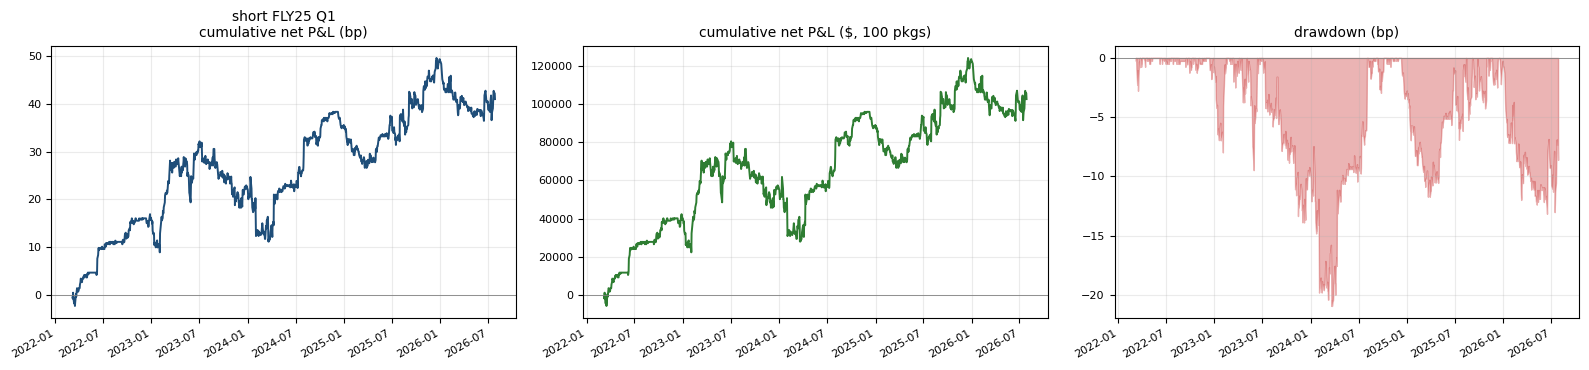

In [4]:
b1, r1, s1 = CONFIG["carry_book"], CONFIG["carry_rank"], CONFIG["carry_side"]
hold1 = build_book(b1, r1, dates, surface, fwd_idx, tree)
pnl1 = book_daily_pnl(hold1, cost_mult=CONFIG["cost_mult"],
                      n_legs=n_contracts(b1))
sign1 = 1.0 if s1 == "long" else -1.0
p1 = pnl1.copy()
mk = p1["kind"].isin(["mark", "settle"])
p1.loc[mk, "pnl_bp"] *= sign1
daily1 = p1.groupby("as_of")["pnl_bp"].sum()
st1 = perf_stats(daily1)
header_block(f"STRATEGY 1: {s1.upper()} {b1} Q{r1} (rolled at expiry-3d, "
             f"re-struck at the tree mode)", st1,
             note=f"{len(hold1)} holdings, costs at "
                  f"{CONFIG['cost_mult']}x half-ticks")
fig = three_panel_equity(daily1, f"{s1} {b1} Q{r1}")
plt.show()

monthly net P&L (bp):
month    1     2    3    4    5    6    7    8    9   10   11   12  YEAR
year                                                                    
2022   NaN   NaN  0.9  2.8  1.0  4.9  1.5  0.0  1.7  2.5  0.8  0.1  16.2
2023  -5.7  10.7  6.3 -1.0 -4.0  9.0 -3.3 -1.3 -2.3  0.2 -5.3  3.2   6.5
2024  -2.4  -6.8 -0.4  9.1  0.8 -0.1  3.9  6.0  0.2  3.8  1.5 -2.7  12.9
2025  -5.5  -0.8 -2.1  0.9  5.2  3.8 -4.9  3.1  5.7  2.7  1.0  4.2  13.3
2026  -4.7  -1.8 -2.1 -2.3  0.7  1.9  0.5  NaN  NaN  NaN  NaN  NaN  -7.8


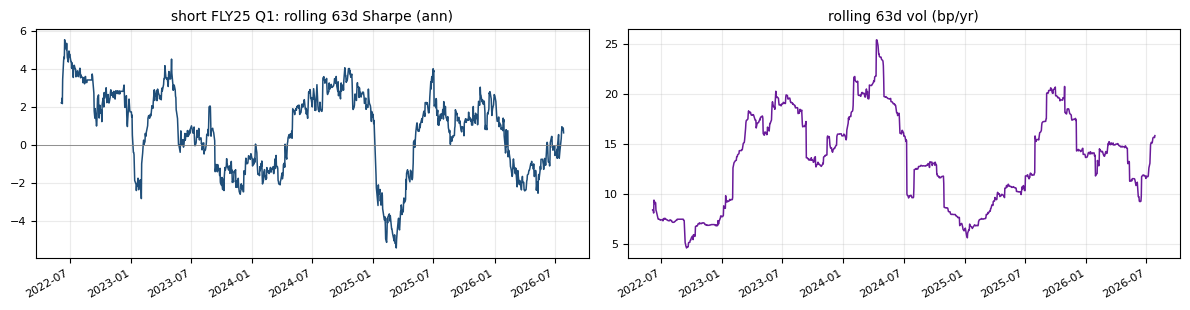

In [5]:
print("monthly net P&L (bp):")
print(monthly_table(daily1).to_string())
fig = rolling_panel(daily1, f"{s1} {b1} Q{r1}")
plt.show()

In [6]:
att1 = attribution(p1, decisions)
print("attribution (bp):")
print(att1.round(1).to_string())
print("\nper-year:")
yearly = daily1.groupby(daily1.index.year).agg(["sum", "count"]).round(1)
yearly.columns = ["net_bp", "days"]
yearly["sharpe"] = daily1.groupby(daily1.index.year).apply(
    lambda d: d.mean() / d.std(ddof=1) * np.sqrt(252)
    if d.std(ddof=1) > 0 else np.nan).round(2)
print(yearly.to_string())
print("\ncost scenarios:")
for m in CONFIG["cost_scenarios"]:
    pm = book_daily_pnl(hold1, cost_mult=m, n_legs=n_contracts(b1))
    pm.loc[pm["kind"].isin(["mark", "settle"]), "pnl_bp"] *= sign1
    tot = pm["pnl_bp"].sum()
    print(f"  x{m}: total {tot:+8.1f}bp  (${tot * DPB:+,.0f})")

attribution (bp):
                  sum  count
bucket                      
costs            -9.5     19
decision_window   7.3     99
ordinary         41.2    985
settlement        2.0     17

per-year:
       net_bp  days  sharpe
as_of                      
2022     16.2   207    2.52
2023      6.5   250    0.39
2024     12.9   252    0.85
2025     13.3   251    0.93
2026     -7.9   142   -0.95

cost scenarios:
  x0.0: total    +50.5bp  ($+126,201)
  x1.0: total    +41.0bp  ($+102,451)
  x2.0: total    +31.5bp  ($+78,701)


In [7]:
term1 = pd.DataFrame([
    {"symbol": h.symbol, "entry": h.marks.index[0].date(),
     "exit": h.marks.index[-1].date(),
     "strikes": "/".join(f"{k:.2f}" for _, k, _ in h.legs),
     "entry_bp": round(float(h.marks.iloc[0]), 2),
     "last_bp": round(float(h.marks.iloc[-1]), 2),
     "settle_bp": (round(float(h.terminal_bp), 2)
                   if h.terminal_bp is not None else np.nan)}
    for h in hold1])
print("holding ledger (the insurance settlements, from the structure's "
      "LONG perspective):")
print(term1.to_string(index=False))

holding ledger (the insurance settlements, from the structure's LONG perspective):
symbol      entry       exit           strikes  entry_bp  last_bp  settle_bp
SFRM22 2022-03-08 2022-06-06 98.75/99.00/99.25      5.18     0.00       0.00
SFRU22 2022-06-07 2022-09-12 97.50/97.75/98.00      6.93     0.00       0.00
SFRZ22 2022-09-13 2022-12-12 95.75/96.00/96.25      5.42     0.00       0.00
SFRH23 2022-12-13 2023-03-06 95.00/95.25/95.50      8.30     1.50       0.00
SFRM23 2023-03-07 2023-06-12 94.25/94.50/94.75      6.27     6.00       0.00
SFRU23 2023-06-13 2023-09-11 94.50/94.75/95.00      6.94     8.25      10.75
SFRZ23 2023-09-12 2023-12-11 94.50/94.75/95.00      6.94    11.24      12.75
SFRH24 2023-12-12 2024-03-11 94.50/94.75/95.00     12.48    18.49      16.50
SFRM24 2024-03-12 2024-06-10 94.75/95.00/95.25      9.05     0.00       0.00
SFRU24 2024-06-11 2024-09-09 94.50/94.75/95.00     11.50     0.00       0.00
SFRZ24 2024-09-10 2024-12-09 95.75/96.00/96.25      4.80     0.00     

## Strategy 2 — the intra-quarter richness fade

STRATEGY 2: FADE STRG75 Q1 richness (thr 4.0bp, exit 25%, hold<= 15d)  |  100 packages ($2,500/bp)
  richness = listed premium - ZQ-tree fair (strict smear); positions exist only while a signal is on
  236 days over 4.1y   trades 16   hit 88%   hit-days 52%
  total     +75.3bp  ($    +188,135)   +18.4bp/yr
  Sharpe +1.62   Sortino +1.99   NW t +2.10   profit factor 1.69
  maxDD -19.7bp ($-49,284, longest 36d)   worst day -16.60bp   best +25.60bp   skew +3.51   kurt 40.0


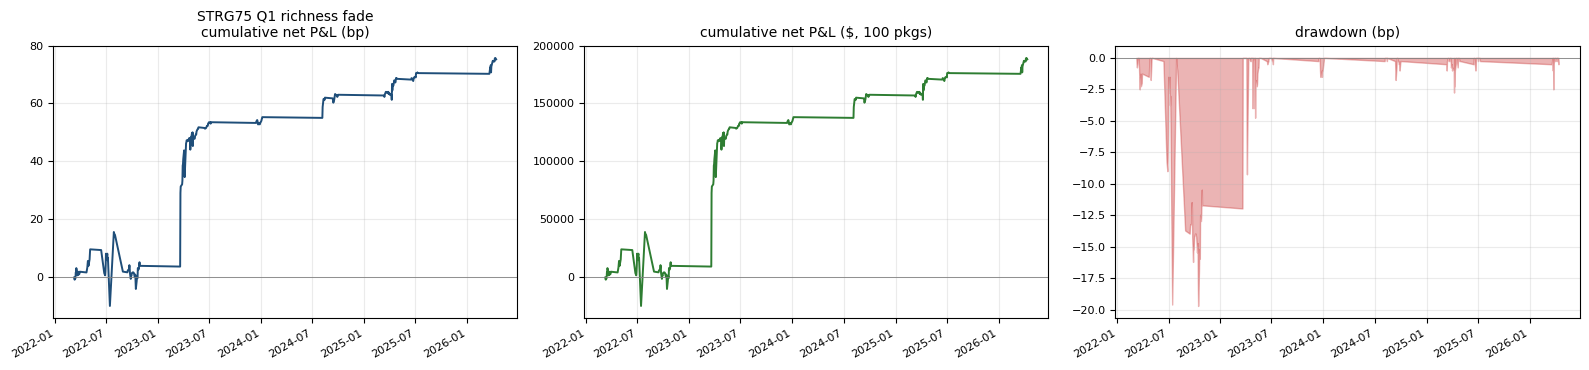

In [8]:
b2, r2 = CONFIG["fade_book"], CONFIG["fade_rank"]
hold2 = build_book(b2, r2, dates, surface, fwd_idx, tree)
trades2 = intra_quarter_backtest(
    hold2, thr_bp=CONFIG["fade_thr_bp"], exit_frac=CONFIG["fade_exit_frac"],
    max_hold=CONFIG["fade_max_hold"], direction=CONFIG["fade_direction"],
    cost_mult=CONFIG["cost_mult"], n_legs=n_contracts(b2))
tl2 = pd.DataFrame(trades2)
daily2 = trades_daily_pnl(trades2, hold2, cost_mult=CONFIG["cost_mult"],
                          n_legs=n_contracts(b2))
st2 = perf_stats(daily2, trades_n=len(tl2),
                 hit=float((tl2["net_bp"] > 0).mean()) if len(tl2) else np.nan)
header_block(
    f"STRATEGY 2: {CONFIG['fade_direction'].upper()} {b2} Q{r2} richness "
    f"(thr {CONFIG['fade_thr_bp']}bp, exit {CONFIG['fade_exit_frac']:.0%}, "
    f"hold<= {CONFIG['fade_max_hold']}d)", st2,
    note="richness = listed premium - ZQ-tree fair (strict smear); "
         "positions exist only while a signal is on")
fig = three_panel_equity(daily2, f"{b2} Q{r2} richness fade")
plt.show()

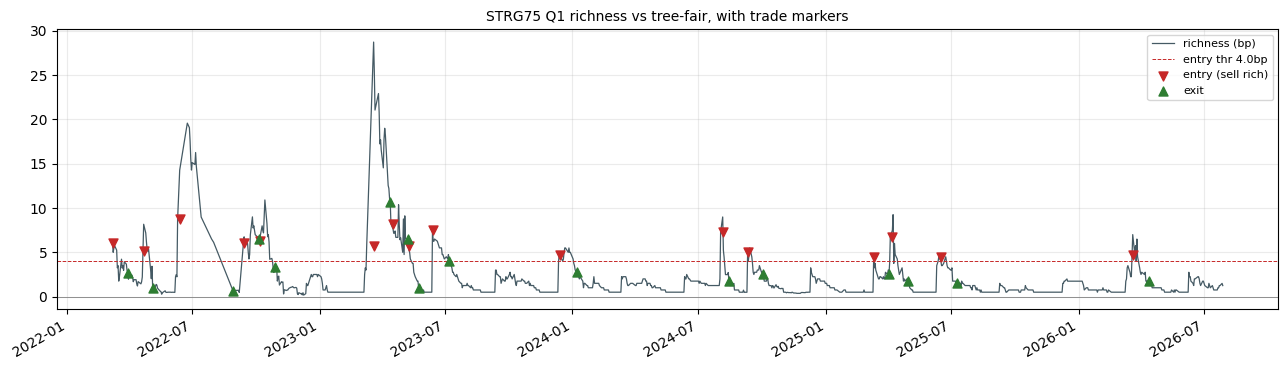

In [9]:
rf2 = richness_frame(hold2)
rs = rf2.groupby("as_of")["rich_bp"].mean()
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(rs.index, rs.values, lw=0.9, color="#455a64", label="richness (bp)")
ax.axhline(0, color="grey", lw=0.6)
ax.axhline(CONFIG["fade_thr_bp"], color="#c62828", lw=0.7, ls="--",
           label=f"entry thr {CONFIG['fade_thr_bp']}bp")
if len(tl2):
    ax.scatter(tl2["entry"], tl2["entry_rich"], marker="v", s=42,
               color="#c62828", zorder=5, label="entry (sell rich)")
    ex = rs.reindex(pd.DatetimeIndex(tl2["exit"])).fillna(0.0)
    ax.scatter(tl2["exit"], ex.values, marker="^", s=42, color="#2e7d32",
               zorder=5, label="exit")
ax.set_title(f"{b2} Q{r2} richness vs tree-fair, with trade markers",
             fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

trade log:
symbol      entry       exit  entry_rich  side  sessions  gross_bp  net_bp
SFRM22 2022-03-09 2022-03-30        6.00  -1.0        15      2.25    1.75
SFRM22 2022-04-22 2022-05-05        5.15  -1.0         9      8.25    7.75
SFRU22 2022-06-13 2022-08-29        8.77  -1.0        14     -7.21   -7.71
SFRZ22 2022-09-14 2022-10-05        6.00  -1.0        15      0.25   -0.25
SFRZ22 2022-10-07 2022-10-28        6.24  -1.0        15      2.75    2.25
SFRM23 2023-03-20 2023-04-13        5.75  -1.0        15     43.97   43.47
SFRM23 2023-04-17 2023-05-08        8.21  -1.0        15      1.25    0.75
SFRM23 2023-05-10 2023-05-24        5.75  -1.0        10      4.25    3.75
SFRU23 2023-06-14 2023-07-07        7.50  -1.0        15      2.25    1.75
SFRH24 2023-12-14 2024-01-08        4.75  -1.0        15      2.25    1.75
SFRU24 2024-08-05 2024-08-14        7.33  -1.0         7      7.25    6.75
SFRZ24 2024-09-11 2024-10-02        5.00  -1.0        15      1.50    1.00
SFRM25 2025-03

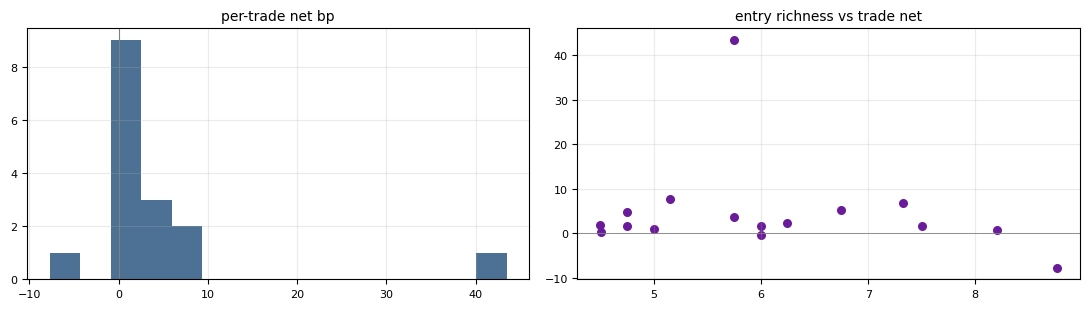

  H1: 10 trades  net +55.3bp  hit 80%
  H2: 6 trades  net +20.0bp  hit 100%

cost scenarios:
  x0.0: total    +83.3bp  ($+208,135)  hit 94%
  x1.0: total    +75.3bp  ($+188,135)  hit 88%
  x2.0: total    +67.3bp  ($+168,135)  hit 81%

monthly net P&L (bp):
month    1    2     3    4    5    6    7     8    9   10   11   12  YEAR
year                                                                     
2022   NaN  NaN   1.8  2.0  5.8 -1.5  7.0 -13.2 -0.5  2.5  0.0  0.0   3.9
2023   0.0  0.0  37.0  7.2  3.8  1.8  0.0   0.0  0.0  0.0  0.0 -0.2  49.6
2024   2.0  0.0   0.0  0.0  0.0  0.0  0.0   6.8  1.0  0.0  0.0  0.0   9.8
2025   0.0  0.0   0.5  5.0  0.0  0.8  1.2   0.0  0.0  0.0  0.0  0.0   7.5
2026   0.0  0.0   4.0  0.8  NaN  NaN  NaN   NaN  NaN  NaN  NaN  NaN   4.8


In [10]:
if len(tl2):
    print("trade log:")
    print(tl2[["symbol", "entry", "exit", "entry_rich", "side", "sessions",
               "gross_bp", "net_bp"]].round(2).to_string(index=False))
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
    axes[0].hist(tl2["net_bp"], bins=15, color="#1f4e79", alpha=0.8)
    axes[0].axvline(0, color="grey", lw=0.8)
    axes[0].set_title("per-trade net bp", fontsize=10)
    axes[1].scatter(tl2["entry_rich"], tl2["net_bp"], s=30, color="#6a1b9a")
    axes[1].axhline(0, color="grey", lw=0.6)
    axes[1].set_title("entry richness vs trade net", fontsize=10)
    for a in axes:
        a.grid(alpha=0.25)
        a.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()
    mid = tl2["entry"].min() + (tl2["entry"].max() - tl2["entry"].min()) / 2
    for nm, seg in (("H1", tl2[tl2["entry"] <= mid]),
                    ("H2", tl2[tl2["entry"] > mid])):
        if len(seg):
            print(f"  {nm}: {len(seg)} trades  net "
                  f"{seg['net_bp'].sum():+.1f}bp  "
                  f"hit {(seg['net_bp'] > 0).mean():.0%}")
    print("\ncost scenarios:")
    rt = 2 * n_contracts(b2) * 0.125
    for m in CONFIG["cost_scenarios"]:
        nets = tl2["gross_bp"] - m * rt
        print(f"  x{m}: total {nets.sum():+8.1f}bp  (${nets.sum() * DPB:+,.0f})"
              f"  hit {(nets > 0).mean():.0%}")
    print("\nmonthly net P&L (bp):")
    print(monthly_table(daily2).to_string())

## The two together

daily correlation (overlapping days): -0.18
COMBINED (1x each, no rebalancing between sleeves)  |  100 packages ($2,500/bp)
  1102 days over 4.39y   hit-days 46%
  total    +116.2bp  ($    +290,585)   +26.5bp/yr
  Sharpe +1.02   Sortino +1.39   NW t +2.19   profit factor 1.32
  maxDD -19.0bp ($-47,379, longest 272d)   worst day -16.85bp   best +25.60bp   skew +4.75   kurt 102.4


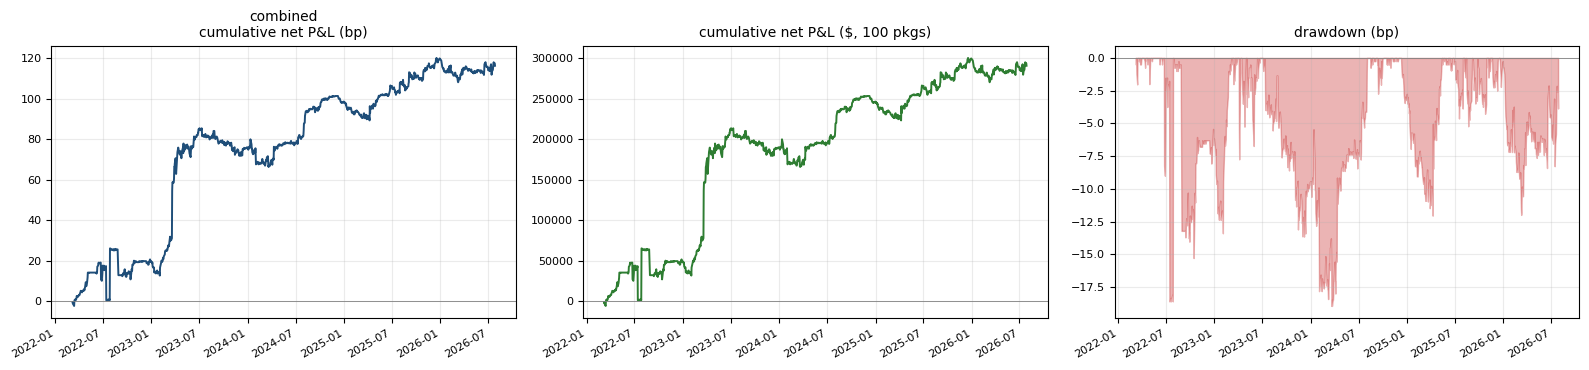

In [11]:
j = pd.concat([daily1.rename("carry"), daily2.rename("fade")], axis=1)
jf = j.fillna(0.0)
corr = j.dropna().corr().iloc[0, 1] if len(j.dropna()) > 20 else np.nan
combo = jf.sum(axis=1)
stc = perf_stats(combo)
print(f"daily correlation (overlapping days): {corr:+.2f}")
header_block("COMBINED (1x each, no rebalancing between sleeves)", stc)
fig = three_panel_equity(combo, "combined")
plt.show()

## Read this before using either number

* The carry short's NW t (printed above) has never cleared 2 on the full
  sample — a real-looking but uncertified income stream whose defined
  risk is the reason it survived 2022–23 at all.
* The fade config is the WINNER of a 720-config search: DSR 0.000, house
  verdict SELECTION-ARTIFACT. Its mechanism (7–18 session richness
  half-lives, frontier-consistent rank levels, positive skew through
  SVB) is measured, but the exact parameters are selection-inflated.
  Running THIS notebook unchanged, forward, is the pre-registered
  one-trial test that discharges the penalty.
* Costs are half-tick models (0.125bp/leg/side at 1x); the 2021–22 era
  was thinner than that. $ figures assume `n_packages` lots at $25/bp
  per contract with no capacity analysis.